In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('WineQT.csv')
print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
df_clean = df.drop(columns=['Id'])
X = df_clean.drop(columns=['quality'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

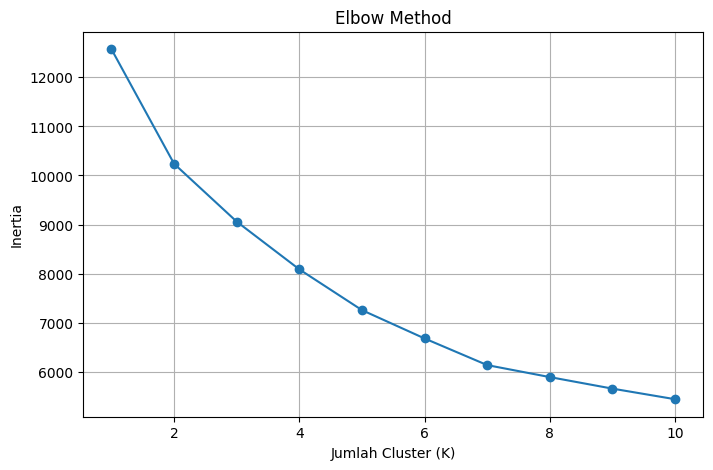

In [3]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [4]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_clean['Cluster'] = kmeans.labels_

print(df_clean['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, kmeans.labels_):.4f}")

Cluster
0    523
1    271
2    349
Name: count, dtype: int64

Silhouette Score: 0.1829


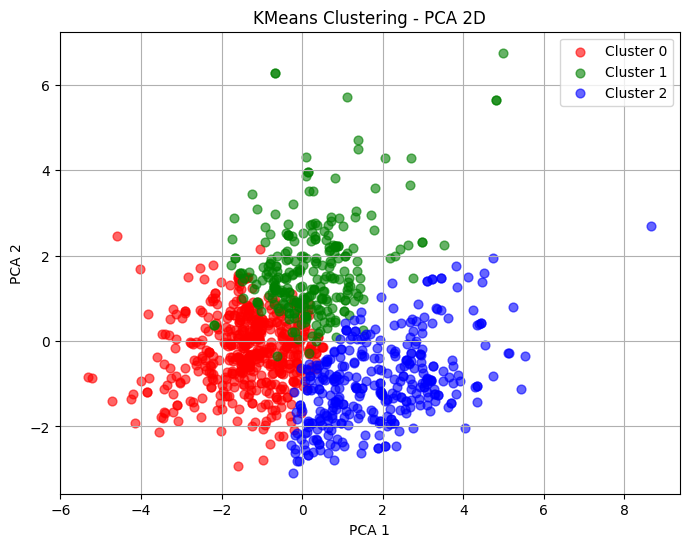

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(k):
    plt.scatter(X_pca[kmeans.labels_ == i, 0],
                X_pca[kmeans.labels_ == i, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.6, s=40)

plt.title('KMeans Clustering - PCA 2D')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0                 7.19              0.61         0.12            2.19   
1                 8.16              0.55         0.28            3.02   
2                10.11              0.41         0.48            2.67   

         chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
Cluster                                                                        
0             0.08                13.39                 34.40      1.0  3.40   
1             0.09                26.27                 88.57      1.0  3.28   
2             0.10                10.68                 30.05      1.0  3.19   

         sulphates  alcohol  quality  
Cluster                               
0             0.61    10.53     5.59  
1             0.62     9.86     5.35  
2             0.75    10.76     6.00  


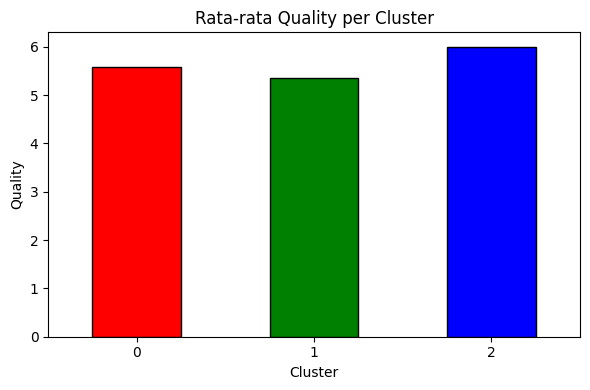

In [6]:
summary = df_clean.groupby('Cluster').mean().round(2)
print(summary)

plt.figure(figsize=(6, 4))
df_clean.groupby('Cluster')['quality'].mean().plot(kind='bar', color=['red', 'green', 'blue'], edgecolor='black')
plt.title('Rata-rata Quality per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Quality')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()